# **1. Download segment-anything**

In [1]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python matplotlib
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth -O sam_vit_b.pth


  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-bznm1xae
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-bznm1xae
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
--2025-05-09 12:28:51--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.33, 3.171.22.118, 3.171.22.68, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b.pth’

sam_vit_b.pth       100%[===================>] 357.67M   259MB/s    in 1.4s    

2025-05-09 12:28:52 (259 MB/s) - ‘sam_vit_b.pth’ saved [375042383/375042383]



Original Image

      ↓
      
[Resize to 512x512]

      ↓
      
[CLAHE (Contrast Limited Adaptive Histogram Equalization)]

      ↓
      
[Gaussian Blur (Smoothing)]

      ↓
[Canny Edge Detection] ──→ Edge Map (for boundary detection)

      ↓
[Sharpening (Enhance details)]

      ↓
[Normalization (Scale to [0,1])]

      ↓
      
Final Preprocessed Image


Each step enhances the image for a specific purpose:

CLAHE: improves contrast.

Gaussian Blur: reduces noise.

Canny: detects edges.

Sharpening: highlights features.

Normalization: prepares for model input.


1.	Canny edge --> good
2.	Sobel operator --> Very good 
3.	Prewitt Operator --> bad
4.	Laplacian of Gaussian (LoG) --> Very bad
5.	Scharr Operator --> good
6.	Roberts Cross Operator --> best
7.	Difference of Gaussians (DoG) -> bad


In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator


# **Canny edge**

(-0.5, 511.5, 511.5, -0.5)

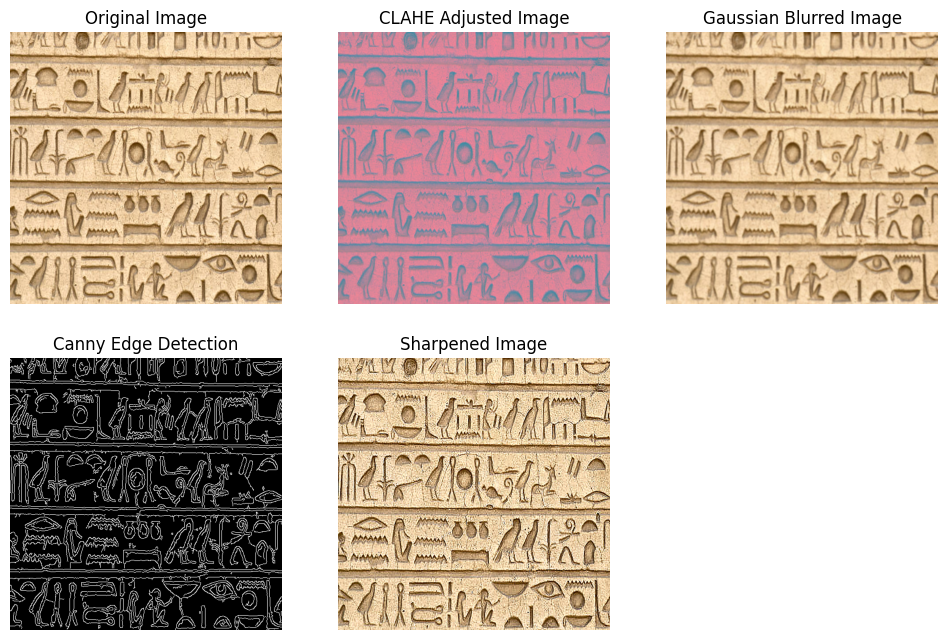

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Load and preprocess image
image_path = "/kaggle/input/sample-image/test.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 1. Resize the image (optional: adjust size as needed)
desired_width, desired_height = 512, 512  # Example size, adjust as needed
image = cv2.resize(image, (desired_width, desired_height))

# 2. Contrast Adjustment using CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))  # Adjusted clipLimit
image_lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)  # Convert to LAB color space
l, a, b = cv2.split(image_lab)  # Split into L, A, B channels
l = clahe.apply(l)  # Apply CLAHE to the L channel (luminance)
image_lab = cv2.merge((l, a, b))  # Merge the channels back
image = cv2.cvtColor(image_lab, cv2.COLOR_LAB2RGB)  # Convert back to RGB

# 3. Smoothing using Gaussian Blur
image_blurred = cv2.GaussianBlur(image, (5, 5), 0)  # Increased kernel size for better smoothing

# 4. Edge Detection using Canny
edges = cv2.Canny(cv2.cvtColor(image_blurred, cv2.COLOR_RGB2GRAY), 50, 150)  # Adjusted thresholds

# 5. Sharpening the image
sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5,-1],
                           [0, -1, 0]])
sharpened = cv2.filter2D(image, -1, sharpen_kernel)

# 6. Normalize image (to range 0 to 1)
image_normalized = image / 255.0

# Display all steps for comparison
plt.figure(figsize=(12, 12))

# Original Image
plt.subplot(3, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

# CLAHE Adjusted Image
plt.subplot(3, 3, 2)
plt.imshow(image_lab)
plt.title("CLAHE Adjusted Image")
plt.axis("off")

# Blurred Image
plt.subplot(3, 3, 3)
plt.imshow(image_blurred)
plt.title("Gaussian Blurred Image")
plt.axis("off")

# Canny Edge Detection
plt.subplot(3, 3, 4)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

# Sharpened Image
plt.subplot(3, 3, 5)
plt.imshow(sharpened)
plt.title("Sharpened Image")
plt.axis("off")





In [4]:
# Load SAM (Segment Anything Model)
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")


/usr/local/lib/python3.11/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


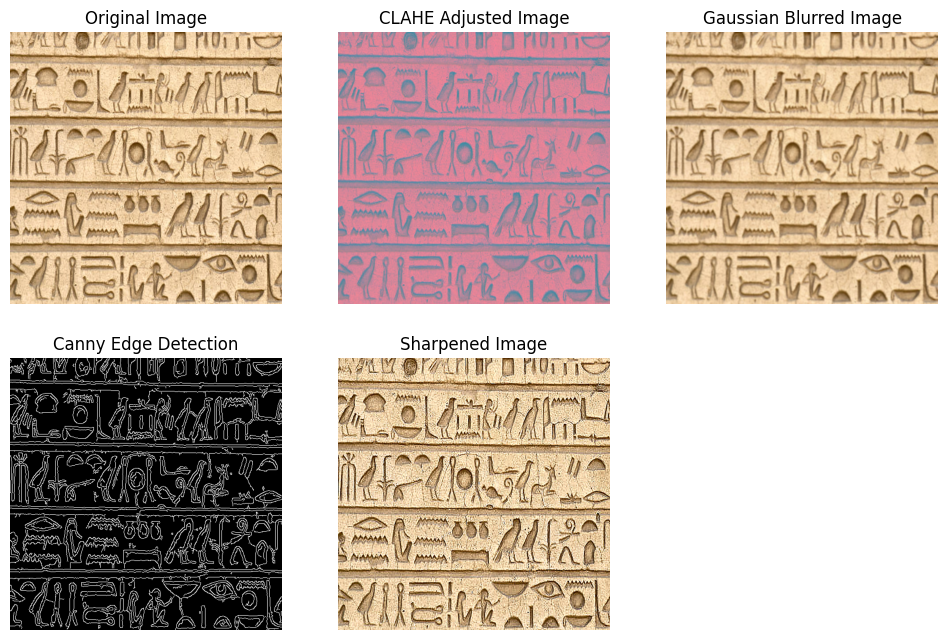

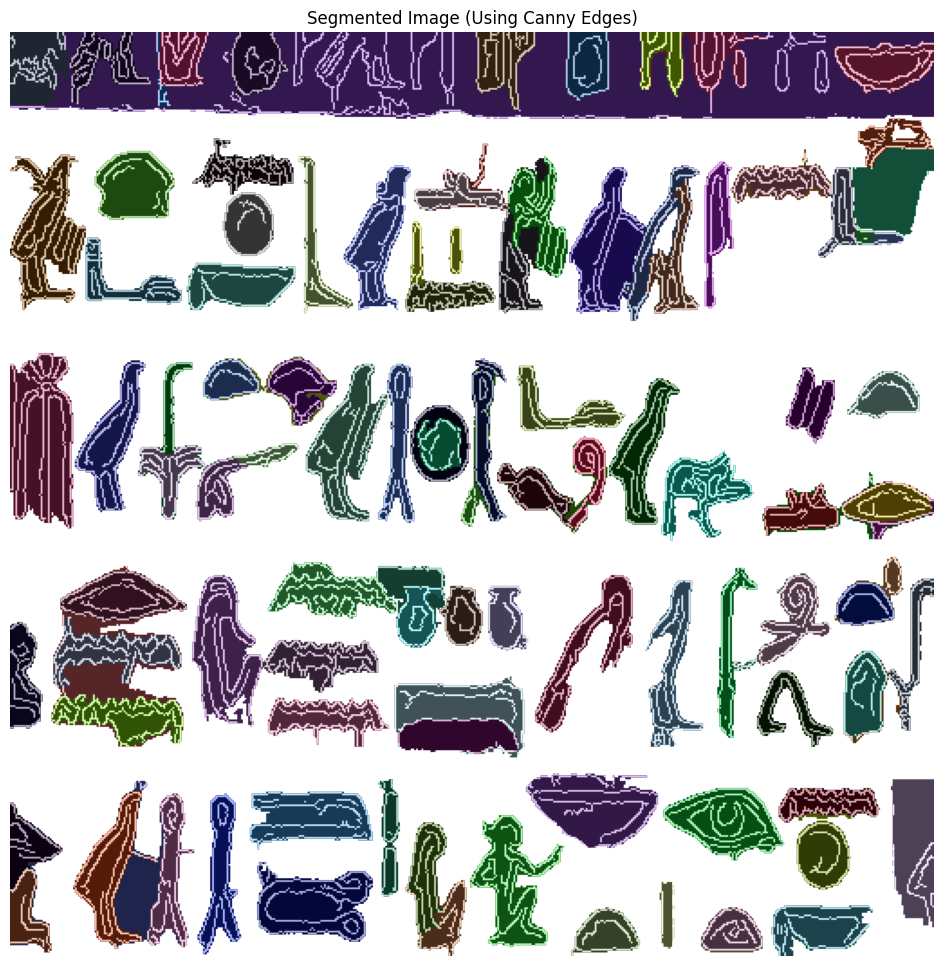

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Load and preprocess image
image_path = "/kaggle/input/sample-image/test.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize image
desired_width, desired_height = 512, 512  # Adjust size as needed
image = cv2.resize(image, (desired_width, desired_height))

# CLAHE Adjustment for contrast
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
image_lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(image_lab)
l = clahe.apply(l)
image_lab = cv2.merge((l, a, b))
image = cv2.cvtColor(image_lab, cv2.COLOR_LAB2RGB)

# Smoothing with Gaussian Blur
image_blurred = cv2.GaussianBlur(image, (5, 5), 0)

# Edge Detection using Canny
edges = cv2.Canny(cv2.cvtColor(image_blurred, cv2.COLOR_RGB2GRAY), 50, 150)

# Sharpening with a kernel
sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv2.filter2D(image, -1, sharpen_kernel)

# Normalize the image (0 to 1)
image_normalized = image / 255.0

# Show preprocessing steps
plt.figure(figsize=(12, 12))
plt.subplot(3, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(3, 3, 2)
plt.imshow(image_lab)
plt.title("CLAHE Adjusted Image")
plt.axis("off")

plt.subplot(3, 3, 3)
plt.imshow(image_blurred)
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.subplot(3, 3, 4)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
plt.axis("off")

plt.subplot(3, 3, 5)
plt.imshow(sharpened)
plt.title("Sharpened Image")
plt.axis("off")

# Load SAM (Segment Anything Model)
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

# Mask generator
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=64,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.85,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=70
)

# Convert edges to a 3D image (replicating the grayscale across 3 channels)
edges_3d = np.stack([edges] * 3, axis=-1)  # Make it (H, W, 3)

# Generate masks from Canny edge image (now with 3D shape)
masks = mask_generator.generate(edges_3d)  # Use the 3D edge-detected image

# Post-processing: Remove irrelevant masks (optional)
def post_process_masks(masks, min_area=500):
    processed_masks = []
    for mask in masks:
        mask_area = np.sum(mask['segmentation'])
        if mask_area > min_area:  # Keep large enough masks
            processed_masks.append(mask)
    return processed_masks

# Remove small noise or irrelevant regions
masks = post_process_masks(masks)

# Visualization function for masks
def show_anns(masks):
    if len(masks) == 0:
        return
    sorted_anns = sorted(masks, key=lambda x: x['area'], reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0],
                   sorted_anns[0]['segmentation'].shape[1], 4))

    for ann in sorted_anns:
        mask = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])  # Random colors for the masks
        img[mask == 1] = color_mask
    ax.imshow(img)

# Show segmentation result overlaid on original Canny edges
plt.figure(figsize=(12, 12))
plt.imshow(edges, cmap="gray")
show_anns(masks)
plt.axis("off")
plt.title("Segmented Image (Using Canny Edges)")
plt.show()


# **Laplacian**

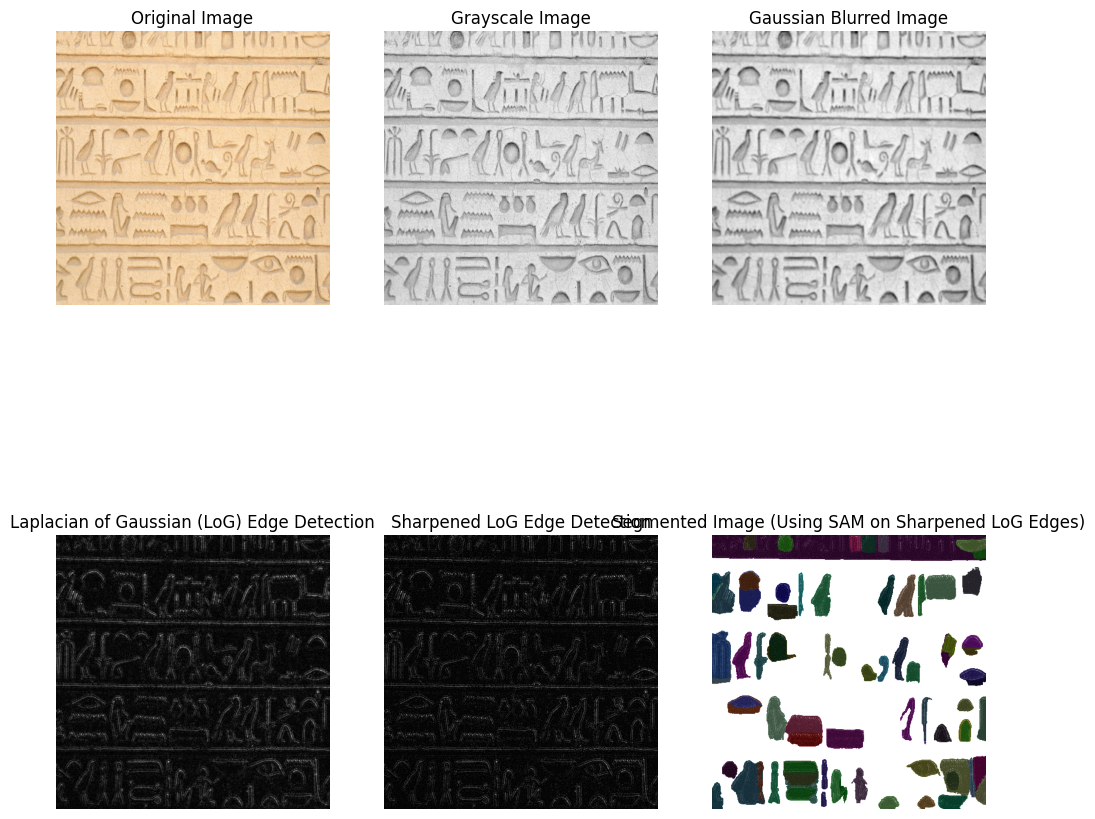

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Load the image
image_path = "/kaggle/input/sample-image/test.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize the image if needed
desired_width, desired_height = 512, 512
image = cv2.resize(image, (desired_width, desired_height))

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Apply Gaussian Blur
gaussian_blurred = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Apply Laplacian of Gaussian (LoG)
laplacian = cv2.Laplacian(gaussian_blurred, cv2.CV_64F)

# Convert the result to a 8-bit image
log_edges = cv2.convertScaleAbs(laplacian)

# Sharpen the edges using unsharp masking
def unsharp_mask(image, sigma=1.0, strength=1.5):
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, 1 + strength, blurred, -strength, 0)
    return sharpened

# Sharpen the LoG edges
sharpened_log_edges = unsharp_mask(log_edges)

# Load SAM (Segment Anything Model)
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

# Mask generator
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=64,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.85,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=70
)

# Convert sharpened LoG edges to a 3D image (replicating the grayscale across 3 channels)
sharpened_log_edges_3d = np.stack([sharpened_log_edges] * 3, axis=-1)  # Make it (H, W, 3)

# Generate masks from the sharpened LoG edge-detected image (now with 3D shape)
masks = mask_generator.generate(sharpened_log_edges_3d)  # Use the 3D sharpened edge-detected image

# Post-processing: Remove irrelevant masks (optional)
def post_process_masks(masks, min_area=500):
    processed_masks = []
    for mask in masks:
        mask_area = np.sum(mask['segmentation'])
        if mask_area > min_area:  # Keep large enough masks
            processed_masks.append(mask)
    return processed_masks

# Remove small noise or irrelevant regions
masks = post_process_masks(masks)

# Visualization function for masks
def show_anns(masks):
    if len(masks) == 0:
        return
    sorted_anns = sorted(masks, key=lambda x: x['area'], reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0],
                   sorted_anns[0]['segmentation'].shape[1], 4))

    for ann in sorted_anns:
        mask = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])  # Random colors for the masks
        img[mask == 1] = color_mask
    ax.imshow(img)

# Plot the images for comparison and segmentation result
plt.figure(figsize=(12, 12))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gaussian_blurred, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(log_edges, cmap="gray")
plt.title("Laplacian of Gaussian (LoG) Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(sharpened_log_edges, cmap="gray")
plt.title("Sharpened LoG Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(sharpened_log_edges, cmap="gray")
show_anns(masks)
plt.title("Segmented Image (Using SAM on Sharpened LoG Edges)")
plt.axis("off")

plt.show()


# **sharpened_sobel_edges**

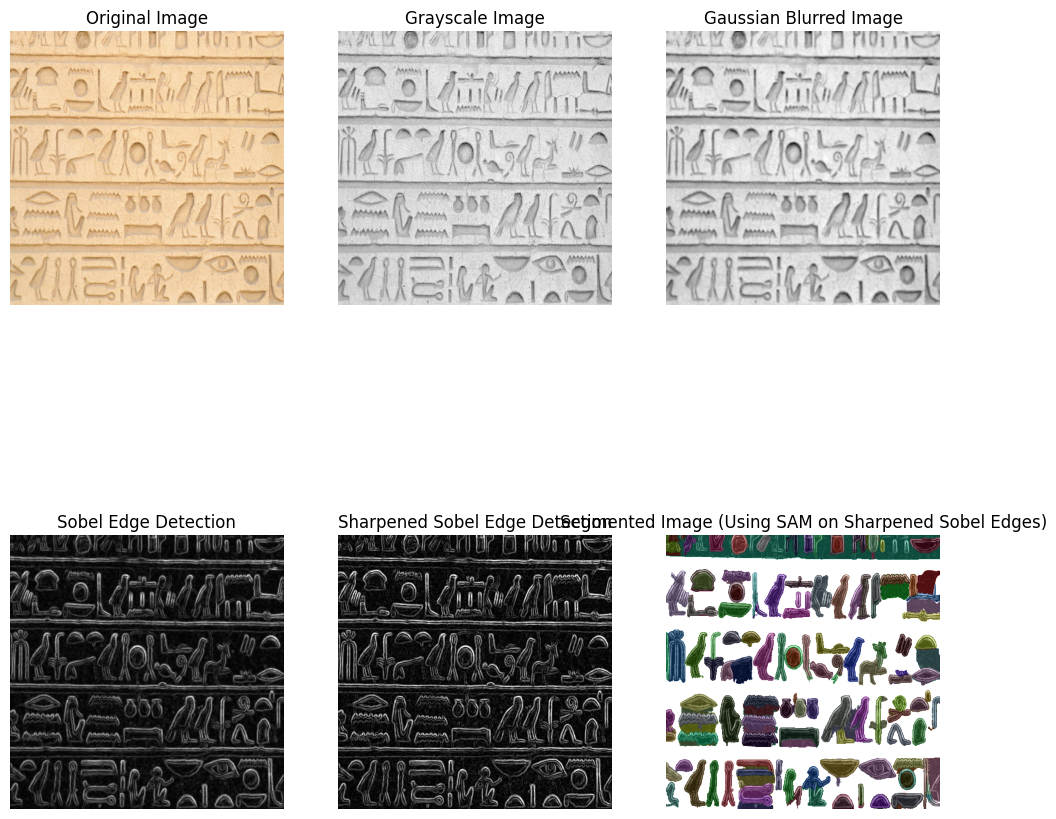

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Load the image
image_path = "/kaggle/input/sample-image/test.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize the image if needed
desired_width, desired_height = 512, 512
image = cv2.resize(image, (desired_width, desired_height))

# Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Apply Gaussian Blur
gaussian_blurred = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Apply Sobel Operator for edge detection (instead of LoG)
sobel_x = cv2.Sobel(gaussian_blurred, cv2.CV_64F, 1, 0, ksize=3)  # Edge detection in x direction
sobel_y = cv2.Sobel(gaussian_blurred, cv2.CV_64F, 0, 1, ksize=3)  # Edge detection in y direction
sobel_edges = cv2.magnitude(sobel_x, sobel_y)  # Combine x and y gradients

# Convert the result to an 8-bit image
sobel_edges_8bit = cv2.convertScaleAbs(sobel_edges)

# Sharpen the edges using unsharp masking
def unsharp_mask(image, sigma=1.0, strength=1.5):
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, 1 + strength, blurred, -strength, 0)
    return sharpened

# Sharpen the Sobel edges
sharpened_sobel_edges = unsharp_mask(sobel_edges_8bit)

# Load SAM (Segment Anything Model)
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

# Mask generator
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=64,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.85,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=70
)

# Convert sharpened Sobel edges to a 3D image (replicating the grayscale across 3 channels)
sharpened_sobel_edges_3d = np.stack([sharpened_sobel_edges] * 3, axis=-1)  # Make it (H, W, 3)

# Generate masks from the sharpened Sobel edge-detected image (now with 3D shape)
masks = mask_generator.generate(sharpened_sobel_edges_3d)  # Use the 3D sharpened edge-detected image

# Post-processing: Remove irrelevant masks (optional)
def post_process_masks(masks, min_area=500):
    processed_masks = []
    for mask in masks:
        mask_area = np.sum(mask['segmentation'])
        if mask_area > min_area:  # Keep large enough masks
            processed_masks.append(mask)
    return processed_masks

# Remove small noise or irrelevant regions
masks = post_process_masks(masks)

# Visualization function for masks
def show_anns(masks):
    if len(masks) == 0:
        return
    sorted_anns = sorted(masks, key=lambda x: x['area'], reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0],
                   sorted_anns[0]['segmentation'].shape[1], 4))

    for ann in sorted_anns:
        mask = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])  # Random colors for the masks
        img[mask == 1] = color_mask
    ax.imshow(img)

# Plot the images for comparison and segmentation result
plt.figure(figsize=(12, 12))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gaussian_blurred, cmap="gray")
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(sobel_edges_8bit, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(sharpened_sobel_edges, cmap="gray")
plt.title("Sharpened Sobel Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(sharpened_sobel_edges, cmap="gray")
show_anns(masks)
plt.title("Segmented Image (Using SAM on Sharpened Sobel Edges)")
plt.axis("off")

plt.show()


# **scharr_edges_8bit**

Original RGB Image shape: (512, 512, 3)
Grayscale Image shape: (512, 512)
Gaussian Blurred Image shape: (512, 512)
Scharr Edge Image shape: (512, 512)
Sharpened Edge Image shape: (512, 512)
3-Channel Sharpened Image shape (for SAM): (512, 512, 3)


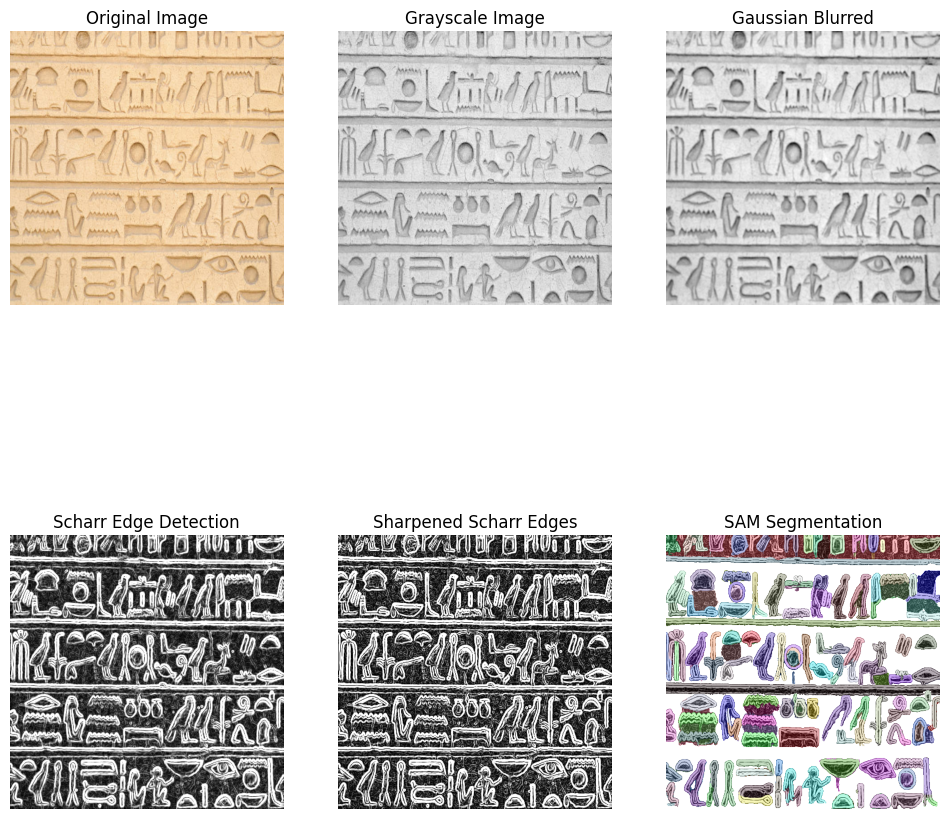

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Load the image
image_path = "/kaggle/input/sample-image/test.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize the image
desired_width, desired_height = 512, 512
image = cv2.resize(image, (desired_width, desired_height))
print("Original RGB Image shape:", image.shape)

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
print("Grayscale Image shape:", gray_image.shape)

# Gaussian Blur
gaussian_blurred = cv2.GaussianBlur(gray_image, (5, 5), 0)
print("Gaussian Blurred Image shape:", gaussian_blurred.shape)

# Scharr Operator
scharr_x = cv2.Scharr(gaussian_blurred, cv2.CV_64F, 1, 0)
scharr_y = cv2.Scharr(gaussian_blurred, cv2.CV_64F, 0, 1)
scharr_edges = cv2.magnitude(scharr_x, scharr_y)
scharr_edges_8bit = cv2.convertScaleAbs(scharr_edges)
print("Scharr Edge Image shape:", scharr_edges_8bit.shape)

# Sharpen using unsharp masking
def unsharp_mask(image, sigma=1.0, strength=1.5):
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, 1 + strength, blurred, -strength, 0)
    return sharpened

sharpened_scharr_edges = unsharp_mask(scharr_edges_8bit)
print("Sharpened Edge Image shape:", sharpened_scharr_edges.shape)

# Load SAM model
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

# SAM mask generator
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=64,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.85,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=70
)

# Prepare 3-channel image
sharpened_edges_3d = np.stack([sharpened_scharr_edges] * 3, axis=-1)
print("3-Channel Sharpened Image shape (for SAM):", sharpened_edges_3d.shape)

# Generate masks
masks = mask_generator.generate(sharpened_edges_3d)

# Post-process masks
def post_process_masks(masks, min_area=500):
    return [mask for mask in masks if np.sum(mask['segmentation']) > min_area]

masks = post_process_masks(masks)

# Visualize masks
def show_anns(masks):
    if not masks:
        return
    sorted_anns = sorted(masks, key=lambda x: x['area'], reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    img = np.ones((*sorted_anns[0]['segmentation'].shape, 4))
    for ann in sorted_anns:
        mask = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[mask == 1] = color_mask
    ax.imshow(img)

# Plotting
plt.figure(figsize=(12, 12))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gaussian_blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(scharr_edges_8bit, cmap="gray")
plt.title("Scharr Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(sharpened_scharr_edges, cmap="gray")
plt.title("Sharpened Scharr Edges")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(sharpened_scharr_edges, cmap="gray")
show_anns(masks)
plt.title("SAM Segmentation")
plt.axis("off")

plt.show()


# **Roberts Edge Detection**

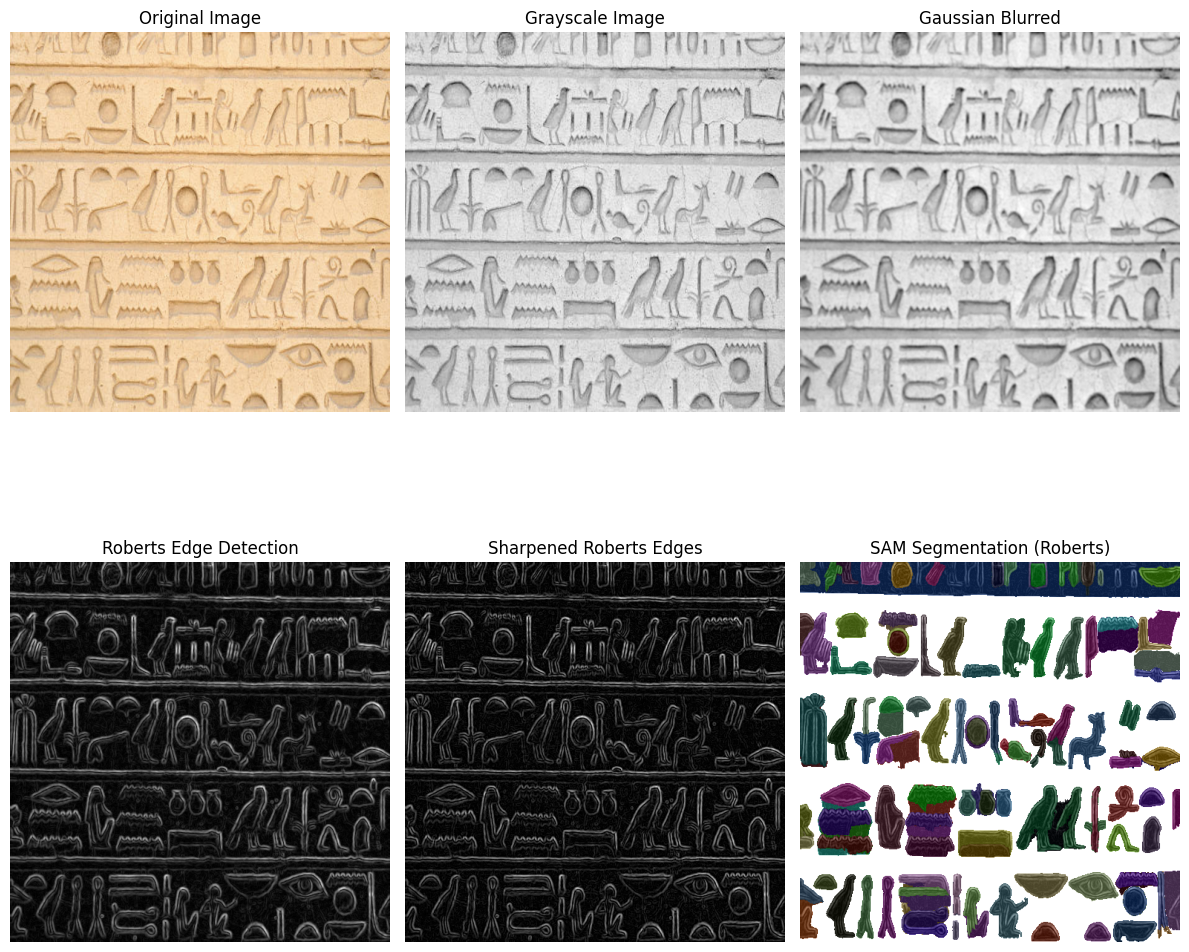

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Load the image
image_path = "/kaggle/input/sample-image/test.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize the image if needed
desired_width, desired_height = 512, 512
image = cv2.resize(image, (desired_width, desired_height))

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Apply Gaussian Blur
gaussian_blurred = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Apply Roberts Cross Operator
roberts_cross_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
roberts_cross_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)
roberts_x = cv2.filter2D(gaussian_blurred, cv2.CV_64F, roberts_cross_x)
roberts_y = cv2.filter2D(gaussian_blurred, cv2.CV_64F, roberts_cross_y)
roberts_edges = cv2.magnitude(roberts_x, roberts_y)

# Convert to 8-bit
roberts_edges_8bit = cv2.convertScaleAbs(roberts_edges)

# Sharpen the edges using unsharp masking
def unsharp_mask(image, sigma=1.0, strength=1.5):
    blurred = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, 1 + strength, blurred, -strength, 0)
    return sharpened

sharpened_roberts_edges = unsharp_mask(roberts_edges_8bit)

# Load SAM
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

# Initialize mask generator
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=64,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.85,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=70
)

# Convert sharpened edges to 3-channel
sharpened_roberts_edges_3d = np.stack([sharpened_roberts_edges]*3, axis=-1)

# Generate masks
masks = mask_generator.generate(sharpened_roberts_edges_3d)

# Post-process masks
def post_process_masks(masks, min_area=500):
    processed_masks = []
    for mask in masks:
        if np.sum(mask['segmentation']) > min_area:
            processed_masks.append(mask)
    return processed_masks

masks = post_process_masks(masks)

# Visualization function
def show_anns(masks):
    if len(masks) == 0:
        return
    sorted_anns = sorted(masks, key=lambda x: x['area'], reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    img = np.ones((sorted_anns[0]['segmentation'].shape[0],
                   sorted_anns[0]['segmentation'].shape[1], 4))
    for ann in sorted_anns:
        mask = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[mask == 1] = color_mask
    ax.imshow(img)

# Plot results
plt.figure(figsize=(12, 12))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gaussian_blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(roberts_edges_8bit, cmap="gray")
plt.title("Roberts Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(sharpened_roberts_edges, cmap="gray")
plt.title("Sharpened Roberts Edges")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(sharpened_roberts_edges, cmap="gray")
show_anns(masks)
plt.title("SAM Segmentation (Roberts)")
plt.axis("off")

plt.tight_layout()
plt.show()


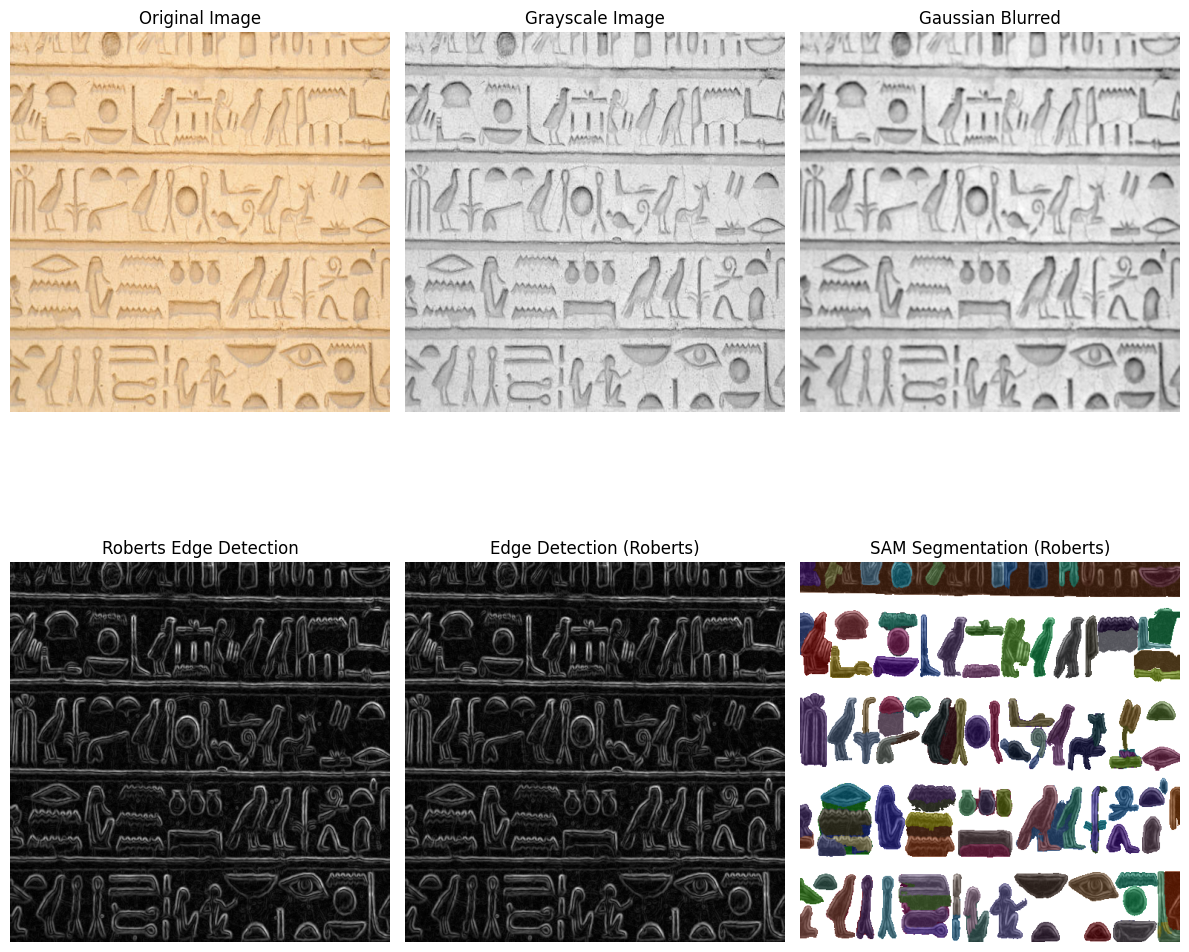

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Load the image
image_path = "/kaggle/input/sample-image/test.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize the image if needed
desired_width, desired_height = 512, 512
image = cv2.resize(image, (desired_width, desired_height))

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Apply Gaussian Blur
gaussian_blurred = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Apply Roberts Cross Operator
roberts_cross_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
roberts_cross_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)
roberts_x = cv2.filter2D(gaussian_blurred, cv2.CV_64F, roberts_cross_x)
roberts_y = cv2.filter2D(gaussian_blurred, cv2.CV_64F, roberts_cross_y)
roberts_edges = cv2.magnitude(roberts_x, roberts_y)

# Convert to 8-bit
roberts_edges_8bit = cv2.convertScaleAbs(roberts_edges)

# Load SAM
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

# Initialize mask generator
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=64,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.85,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=70
)

# Convert sharpened edges to 3-channel
roberts_edges_3d = np.stack([roberts_edges_8bit]*3, axis=-1)

# Generate masks
masks = mask_generator.generate(roberts_edges_3d)

# Post-process masks
def post_process_masks(masks, min_area=500):
    processed_masks = []
    for mask in masks:
        if np.sum(mask['segmentation']) > min_area:
            processed_masks.append(mask)
    return processed_masks

masks = post_process_masks(masks)

# Visualization function
def show_anns(masks):
    if len(masks) == 0:
        return
    sorted_anns = sorted(masks, key=lambda x: x['area'], reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    img = np.ones((sorted_anns[0]['segmentation'].shape[0],
                   sorted_anns[0]['segmentation'].shape[1], 4))
    for ann in sorted_anns:
        mask = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[mask == 1] = color_mask
    ax.imshow(img)

# Plot results
plt.figure(figsize=(12, 12))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(gaussian_blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(roberts_edges_8bit, cmap="gray")
plt.title("Roberts Edge Detection")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(roberts_edges_8bit, cmap="gray")
plt.title("Edge Detection (Roberts)")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(roberts_edges_8bit, cmap="gray")
show_anns(masks)
plt.title("SAM Segmentation (Roberts)")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# Load the image
image_path = "/kaggle/input/sample-image/test.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize the image if needed
desired_width, desired_height = 512, 512
image = cv2.resize(image, (desired_width, desired_height))

# Convert to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# Apply Gaussian Blur
gaussian_blurred = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Apply Roberts Cross Operator
roberts_cross_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
roberts_cross_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)
roberts_x = cv2.filter2D(gaussian_blurred, cv2.CV_64F, roberts_cross_x)
roberts_y = cv2.filter2D(gaussian_blurred, cv2.CV_64F, roberts_cross_y)
roberts_edges = cv2.magnitude(roberts_x, roberts_y)

# Convert to 8-bit
roberts_edges_8bit = cv2.convertScaleAbs(roberts_edges)

# Load SAM
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

# Initialize mask generator
mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=64,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.85,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=70
)

# Convert sharpened edges to 3-channel
roberts_edges_3d = np.stack([roberts_edges_8bit]*3, axis=-1)

# Generate masks
masks = mask_generator.generate(roberts_edges_3d)

# Post-process masks
def post_process_masks(masks, min_area=500):
    processed_masks = []
    for mask in masks:
        if np.sum(mask['segmentation']) > min_area:
            processed_masks.append(mask)
    return processed_masks

masks = post_process_masks(masks)

# Print and show the individual masks
def print_and_show_anns(masks):
    if len(masks) == 0:
        print("No masks detected.")
        return
    
    sorted_anns = sorted(masks, key=lambda x: x['area'], reverse=True)
    
    for idx, ann in enumerate(sorted_anns):
        print(f"Mask {idx + 1}:")
        print(f"  - Shape: {ann['segmentation'].shape}")
        print(f"  - Area: {np.sum(ann['segmentation'])} pixels")
        print(f"  - Bounding box: {ann['bbox']}")
        
        # Optionally, show the mask itself
        plt.figure(figsize=(6, 6))
        plt.imshow(ann['segmentation'], cmap="gray")
        plt.title(f"Mask {idx + 1}")
        plt.axis("off")
        plt.show()

# Show segmentation result overlaid on original image
plt.figure(figsize=(12, 12))
plt.imshow(roberts_edges_8bit, cmap="gray")
show_anns(masks)
plt.axis("off")
plt.title("Segmented Image (Using Roberts Edge Detection)")
plt.show()

# Call the function to print and show each individual mask
print_and_show_anns(masks)


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Make sure this is included!
os.makedirs("extracted_shapes", exist_ok=True)

for idx, mask_info in enumerate(masks):
    mask = mask_info['segmentation']
    
    # Create an RGBA image (4 channels) with zeros
    extracted_shape_rgba = np.zeros((image.shape[0], image.shape[1], 4), dtype=np.uint8)
    
    # Copy RGB channels from original image where mask is True
    extracted_shape_rgba[mask, :3] = image[mask]
    
    # Set alpha channel to 255 where mask is True, else 0 (transparent background)
    extracted_shape_rgba[mask, 3] = 255
    
    # Save as PNG with transparency
    save_path = os.path.join("extracted_shapes", f"shape_alpha_{idx+1}.png")
    cv2.imwrite(save_path, cv2.cvtColor(extracted_shape_rgba, cv2.COLOR_RGBA2BGRA))
    
    # Display with plt
    plt.figure(figsize=(4, 4))
    plt.imshow(extracted_shape_rgba)
    plt.axis('off')
    plt.title(f"Extracted Shape with Transparency {idx+1}")
    plt.show()

In [ ]:
def sort_masks_rowwise(masks, row_threshold=20):
    # Sort masks by y coordinate first (top to bottom)
    masks = sorted(masks, key=lambda m: m['bbox'][1])

    rows = []
    current_row = []
    current_y = None

    for mask in masks:
        x, y, w, h = mask['bbox']

        if current_y is None:
            current_y = y
            current_row.append(mask)
        else:
            # If mask y is close enough to current row y, it belongs in the same row
            if abs(y - current_y) <= row_threshold:
                current_row.append(mask)
            else:
                # Sort current row by x coordinate (left to right)
                current_row = sorted(current_row, key=lambda m: m['bbox'][0])
                rows.append(current_row)

                # Start new row
                current_row = [mask]
                current_y = y

    # Append the last row after loop ends
    if current_row:
        current_row = sorted(current_row, key=lambda m: m['bbox'][0])
        rows.append(current_row)

    # Flatten the sorted rows into a single list
    sorted_rowwise_masks = [mask for row in rows for mask in row]
    return sorted_rowwise_masks


# Use this function before extracting shapes
sorted_masks = sort_masks_rowwise(masks)

# Now you can proceed to extract/display masks in row-wise order
for idx, mask_info in enumerate(sorted_masks):
    mask = mask_info['segmentation']
    # extract the shape as before

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from sklearn.cluster import DBSCAN

# --- Load and preprocess image ---
image_path = "/kaggle/input/sample-image/test.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
desired_width, desired_height = 512, 512
image = cv2.resize(image, (desired_width, desired_height))

gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
gaussian_blurred = cv2.GaussianBlur(gray_image, (5, 5), 0)

# Roberts Cross Operator
roberts_cross_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
roberts_cross_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)
roberts_x = cv2.filter2D(gaussian_blurred, cv2.CV_64F, roberts_cross_x)
roberts_y = cv2.filter2D(gaussian_blurred, cv2.CV_64F, roberts_cross_y)
roberts_edges = cv2.magnitude(roberts_x, roberts_y)
roberts_edges_8bit = cv2.convertScaleAbs(roberts_edges)

# --- Load SAM model ---
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
sam.to("cuda" if torch.cuda.is_available() else "cpu")

mask_generator = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=64,
    pred_iou_thresh=0.8,
    stability_score_thresh=0.85,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=70
)

roberts_edges_3d = np.stack([roberts_edges_8bit]*3, axis=-1)
masks = mask_generator.generate(roberts_edges_3d)

def post_process_masks(masks, min_area=500):
    return [m for m in masks if np.sum(m['segmentation']) > min_area]

masks = post_process_masks(masks)

# --- Improved row-wise sorting with DBSCAN clustering ---
def cluster_rows(masks, eps=15, min_samples=1):
    """
    Cluster masks into rows using DBSCAN on vertical coordinate (bbox top y).
    eps controls max vertical distance between items in same cluster (row).
    """
    ys = np.array([mask['bbox'][1] for mask in masks]).reshape(-1, 1)
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(ys)
    labels = clustering.labels_

    unique_labels = sorted(set(labels))
    rows = []
    for label in unique_labels:
        row_masks = [masks[i] for i in range(len(masks)) if labels[i] == label]
        # Sort this row left to right
        row_masks = sorted(row_masks, key=lambda m: m['bbox'][0])
        rows.append(row_masks)

    # Sort rows top to bottom by mean y position
    rows = sorted(rows, key=lambda row: np.mean([m['bbox'][1] for m in row]))

    # Flatten the list
    return [mask for row in rows for mask in row]

sorted_masks = cluster_rows(masks, eps=20)  # eps can be adjusted per use case/image

# Directory to save extracted shapes
output_dir = "extracted_shapes"
os.makedirs(output_dir, exist_ok=True)

# Extract and save/display each shape as RGBA with transparency
for idx, mask_info in enumerate(sorted_masks):
    mask = mask_info['segmentation']
    
    extracted_rgba = np.zeros((image.shape[0], image.shape[1], 4), dtype=np.uint8)
    extracted_rgba[mask, :3] = image[mask]  # RGB channels
    extracted_rgba[mask, 3] = 255            # Alpha channel
    
    save_path = os.path.join(output_dir, f"shape_rowwise_clustered_{idx+1}.png")
    cv2.imwrite(save_path, cv2.cvtColor(extracted_rgba, cv2.COLOR_RGBA2BGRA))
    
    plt.figure(figsize=(4, 4))
    plt.imshow(extracted_rgba)
    plt.axis('off')
    plt.title(f"Extracted Shape {idx + 1} (Clustered row-wise)")
    plt.show()